# The reproducible result, and how uncertain it is

**Two ways to use this notebook.**

1. **Execute it.** Cell by cell, or `jupyter nbconvert --to notebook --execute
   uq_reproducible_result.ipynb`. It reproduces the reported wave speed from scratch in
   about a minute and checks it against a stored reference. Everything heavier loads from
   cached CSVs in `results/`.
2. **Read it.** Every cell says what you should see before you run it, so the notebook
   doubles as the written protocol. Appendix C of the report points here.

What it establishes, in order: the wave speed at a fixed operating point with its two
error bars, that the size and the structure of the parametric error bar both follow from
the closed form rather than from a separate analysis, and that per-diaphragm disorder is a
different question with a much smaller answer.

In [1]:
import os, sys, time, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sys.path.insert(0, 'src')
from model import run_sim
from plotstyle import use, C, save, width, two_panel, label_line
use()

FORCE_RERUN = False

def load_uq(path):
    if not os.path.exists(path):
        raise SystemExit(f"{path} missing - generate it with: python3 scripts/uq_sweep.py")
    return pd.read_csv(path, comment='#')

train = load_uq('results/uq_train.csv')
test  = load_uq('results/uq_test.csv')
print(f"loaded {len(train)} training runs, {len(test)} test runs")
print(f"all propagated: {train['v_sim'].notna().all() and test['v_sim'].notna().all()}")

print(f"\npython {platform.python_version()}   numpy {np.__version__}   "
      f"pandas {pd.__version__}   matplotlib {matplotlib.__version__}")
print(f"platform {platform.platform()}")


loaded 256 training runs, 32 test runs
all propagated: True

python 3.14.7   numpy 2.3.4   pandas 2.3.3   matplotlib 3.10.7
platform macOS-26.5.2-arm64-arm-64bit-Mach-O


## Background

A row of bistable diaphragms sealed into a pipe, each pair separated by a pocket of gas
obeying Boyle's law. Switch one diaphragm and it squeezes its neighbour's pocket, which can
switch the next: a transition wave travels along the row. `src/model.py` integrates that
chain in physical units; the four-group dimensionless form and its analysis live in
`dimensionless_model.ipynb`.

The report derives a closed form for the wave speed,

$$v = \frac{3\,\Pi\sqrt{2\kappa}}{2\,\Omega},$$

and substituting the group definitions leaves something much simpler in the three
quantities a manufacturer cannot control exactly:

$$v \;\propto\; \frac{\delta A}{\alpha}.$$

Each to the **first power**: the well asymmetry $\delta$, the diaphragm area $A$, and the
damping $\alpha$. Everything below is a consequence of that one proportionality, so it is
worth holding onto. It predicts how big the uncertainty will be, how the three parameters
share it, and how per-site disorder is suppressed.

"Reproducible result" here means a specific number, at a specific operating point, with two
error bars that are kept apart on purpose:

- **numerical** — how much the answer moves if you refine the discretisation
- **parametric** — how much it moves if the hardware is built to tolerance

## Parameters

The operating point below is called the *protocol point* throughout the report.

| parameter | value | reason |
|---|---|---|
| `A` | 1.0 | Diaphragm area. Sets the coupling; enters $\eta$ and $\theta$ both, so $\kappa \propto A^2$. |
| `delta` | 0.001 | Well asymmetry, the drive. Bistability needs $\lvert\delta\rvert < 2a^3/3\sqrt3 \approx 0.0104$, so this is well inside. |
| `alpha` | 0.10 | Damping. In groups $\Omega = 0.33$ — lightly damped, which is what a real diaphragm in gas would be. The canonical point used elsewhere in the report sits at $\Omega = 10$, heavily overdamped, which is numerically convenient rather than device-like. |
| `N` | 200 | Lattice sites. The measured speed is flat beyond $N \approx 100$; 200 leaves margin. |
| `T` | 400 | Run time. Long enough for the front to cross ~70 sites in the bulk, clear of the sponge layers. |
| `dt` | 1e-4 | Set by the stability of the snapping events, not by the accuracy of the front. |

**Why not a more central operating point?** Three reasons. The energy-balance formula is
accurate to 0.04% here, so nothing is lost — the damping curve is flat from $\Omega \approx
0.3$ upwards and this sits at the start of that plateau, not on the slope. The uncertainty
analysis is the part of the project about a manufacturable object, so it belongs at the
device-like operating point. And the numerical error bar comes from convergence studies run
at this same point, so both error bars refer to one place rather than two.

In [2]:
# ── The single reproducible run (cached like every other expensive result) ────
CSV_PROTO = 'results/protocol_point.csv'
if FORCE_RERUN or not os.path.exists(CSV_PROTO):
    t0 = time.perf_counter()
    v_p, v_pred_p, ratio_p = run_sim(A=1.0, delta=0.001, alpha=0.10, N=200, T=400, dt=1e-4)
    pd.DataFrame([dict(v_sim=v_p, v_pred=v_pred_p, ratio=ratio_p,
                       wall_seconds=time.perf_counter()-t0)]).to_csv(CSV_PROTO, index=False)
row = pd.read_csv(CSV_PROTO).iloc[0]
v_protocol = row['v_sim']
print(f"protocol-point wave speed: v = {v_protocol:.4f} sites per unit time")
print(f"(energy-balance prediction {row['v_pred']:.4f}, ratio {row['ratio']:.3f} "
      f"- inside the validity region mapped in dimensionless_model.ipynb)")

# The reference value this notebook is checked against. Executing this cell IS the
# reproducibility test: a mismatch stops the notebook rather than passing quietly.
V_REFERENCE = 0.2205603205452594
if abs(v_protocol - V_REFERENCE) > 1e-6:
    raise AssertionError(
        f"v = {v_protocol!r} does not match the reference {V_REFERENCE!r}.\n"
        "The lattice run is deterministic, so this should reproduce exactly on any\n"
        "machine with the pinned dependency versions. A mismatch means either the\n"
        "simulator has changed or the environment differs in a way that matters;\n"
        "check requirements.txt before trusting anything downstream.")
print(f"\nPASS  matches the reference to better than 1e-6")


protocol-point wave speed: v = 0.2206 sites per unit time
(energy-balance prediction 0.2206, ratio 1.000 - inside the validity region mapped in dimensionless_model.ipynb)

PASS  matches the reference to better than 1e-6


### What you should see

```
protocol-point wave speed: v = 0.2206 sites per unit time
(energy-balance prediction 0.2206, ratio 1.000 - inside the validity region ...)

PASS  matches the reference to better than 1e-6
```

About 50 seconds on one core, or instant if `results/protocol_point.csv` is already there.
Delete that file to force a real run.

The ratio of 1.000 is the energy-balance formula against the simulation at this point. The
report quotes 0.2% for fronts of three sites or more; this front is 4.7 sites wide and comes
out at 0.04%, so the protocol point is comfortably inside the formula's range rather than
near its edge.

A failure here is not a rounding issue. The lattice run is fully deterministic, so it should
reproduce bit-for-bit given the pinned versions in `requirements.txt`.

## How uncertain is that number?

Two sources, kept separate.

**Numerical.** From the convergence studies in `diaphragm_metafluid.ipynb`: $v$ is unchanged
to four decimal places for $N \ge 100$, and halving the timestep changes nothing at the
fourth decimal. A conservative bar is $\pm 0.0001$.

**Parametric.** Suppose each of $\delta$, $A$ and $\alpha$ is only known to $\pm10\%$ — the
sort of tolerance a manufacturer quotes. The set of parameter combinations you might
actually get is then a **box** in three dimensions. We cannot run every point in it, so we
run 256 and take the standard deviation of the resulting speeds.

The 256 are chosen by **Latin hypercube sampling**, which means: chop each parameter's range
into 256 equal strips, and place exactly one sample in every strip of every parameter. Within
its strip each sample sits at random, so this is not a grid — it is random sampling with the
clumping removed. Plain random sampling would by chance oversample some values of $\delta$
and never test others, and the answer would depend on which corner got missed.

That ensemble is generated by `python3 scripts/uq_sweep.py` (about 40 minutes on 8 cores) and
ships as `results/uq_train.csv`, so the cell below is instant.

spread in v across 256 runs : 9.90%   (closed form predicts 10.00%)
spread in v*alpha/(delta*A)   : 0.45%

the same combination with one dependence deliberately wrong:
   A omitted    :  5.85%
   A squared    :  5.78%
   alpha omitted:  5.49%


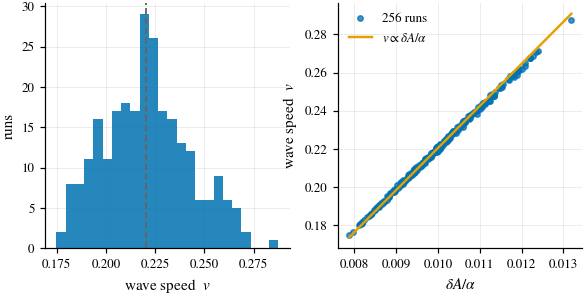


REPRODUCIBLE RESULT:
  v = 0.2206  +/- 0.0001 (numerical)  +/- 0.0219 (parametric, +/-10% tolerances)
  the tolerance band is ~219x the numerical one - manufacturing precision, not the simulation, limits how well v can be known



**The band is what the closed form says it should be.** Across the ensemble the
speed spreads by **9.90%**, against the **10.0%** that three
independent first-power dependencies on a $\pm10\%$ box predict.

**And the proportionality holds directly.** $v\alpha/\delta A$ varies by
**0.45%** across all 256 runs, down from 9.90% for $v$
itself. Omitting any one of the three dependencies, or squaring $A$, leaves about 6%, so
the collapse is a discriminating test and not an identity. The residual
0.45% is the accuracy of the closed form itself in this regime, which the
validity map puts at a fraction of a percent.

**So the uncertainty budget is the closed form checked a second way**, not a separate
exercise: same formula, same regime, tested against an ensemble instead of against a
single simulated speed.


In [3]:
# ── The headline number, and a direct check on where it comes from ───────────
#
# The closed form reduces, in the three parameters carrying tolerances, to
#
#     v ~ delta * A / alpha,
#
# each to the first power. Two consequences, both tested here.
#
#  1. Size. Three independent uniform +/-10% inputs each contribute a relative
#     standard deviation of 0.10/sqrt(3); first order, they add in quadrature to
#     0.10. So the spread in v should be about 10%.
#  2. Structure. The combination v*alpha/(delta*A) should be the same number in
#     every run. Dividing out a dependence that is wrong will not collapse it,
#     which is what makes this a test rather than a restatement.

REL   = 0.10
ens   = train.dropna(subset=['v_sim'])
v_ens = ens.v_sim

sigma_param = float(v_ens.std(ddof=1))
sigma_num   = 1e-4                      # conservative, from the convergence studies
spread      = lambda x: 100*x.std(ddof=1)/x.mean()
comb        = v_ens*ens.alpha/(ens.delta*ens.A)

print(f"spread in v across {len(ens)} runs : {spread(v_ens):.2f}%"
      f"   (closed form predicts {100*REL:.2f}%)")
print(f"spread in v*alpha/(delta*A)   : {spread(comb):.2f}%")
print("\nthe same combination with one dependence deliberately wrong:")
for name, x in [("A omitted    ", v_ens*ens.alpha/ens.delta),
                ("A squared    ", v_ens*ens.alpha/(ens.delta*ens.A**2)),
                ("alpha omitted", v_ens/(ens.delta*ens.A))]:
    print(f"   {name}: {spread(x):5.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=two_panel(2.9))
ax1.hist(v_ens, bins=24, color=C.data, alpha=0.85)
ax1.axvline(v_protocol, color=C.ref, ls='--', lw=1.2)
ax1.set_xlabel(r'wave speed  $v$'); ax1.set_ylabel('runs')

x  = ens.delta*ens.A/ens.alpha
xx = np.linspace(x.min(), x.max(), 50)
ax2.plot(x, v_ens, 'o', color=C.data, ms=3.5, alpha=0.75, label='256 runs')
ax2.plot(xx, comb.mean()*xx, '-', color=C.theory, lw=1.6,
         label=r'$v \propto \delta A/\alpha$')
ax2.set_xlabel(r'$\delta A/\alpha$'); ax2.set_ylabel(r'wave speed  $v$')
ax2.legend(loc='upper left')
plt.show()

print(f"\nREPRODUCIBLE RESULT:")
print(f"  v = {v_protocol:.4f}  +/- {sigma_num:.4f} (numerical)"
      f"  +/- {sigma_param:.4f} (parametric, +/-10% tolerances)")
print(f"  the tolerance band is ~{sigma_param/sigma_num:.0f}x the numerical one - "
      f"manufacturing precision, not the simulation, limits how well v can be known")

display(Markdown(f"""
**The band is what the closed form says it should be.** Across the ensemble the
speed spreads by **{spread(v_ens):.2f}%**, against the **{100*REL:.1f}%** that three
independent first-power dependencies on a $\\pm10\\%$ box predict.

**And the proportionality holds directly.** $v\\alpha/\\delta A$ varies by
**{spread(comb):.2f}%** across all {len(ens)} runs, down from {spread(v_ens):.2f}% for $v$
itself. Omitting any one of the three dependencies, or squaring $A$, leaves about 6%, so
the collapse is a discriminating test and not an identity. The residual
{spread(comb):.2f}% is the accuracy of the closed form itself in this regime, which the
validity map puts at a fraction of a percent.

**So the uncertainty budget is the closed form checked a second way**, not a separate
exercise: same formula, same regime, tested against an ensemble instead of against a
single simulated speed.
"""))


### Reading the figure, and what you should see

**Left** — the 256 speeds as a histogram, with the protocol point marked. The width of this
distribution is the parametric error bar.

**Right** — each run's speed against $\delta A/\alpha$. If the closed form is right this is
a straight line through the origin, and it is. This is the whole claim in one picture.

```
spread in v across 256 runs : 9.90%
spread in v*alpha/(delta*A) : 0.45%

the same combination with one dependence deliberately wrong:
   A omitted    :  5.85%
   A squared    :  5.78%
   alpha omitted:  5.49%
```

Dividing out $\delta A/\alpha$ removes 95% of the variation. The point of the three wrong
versions is that this is a **test** and not an identity: get any single dependence wrong and
the collapse fails, leaving about 6%.

The residual 0.45% is the accuracy of the closed form itself in this regime, which is the
same fraction of a percent the validity map reports.

### Try it yourself

**1. Shrink the tolerance box.** Restrict the ensemble to samples within $\pm5\%$ of nominal
on all three parameters, then $\pm2.5\%$:

```python
m = np.ones(len(ens), bool)
for c, v in (('delta', 0.001), ('A', 1.0), ('alpha', 0.10)):
    m &= (ens[c] >= v*0.95) & (ens[c] <= v*1.05)
print(spread(ens[m].v_sim))
```

You get **5.12%** at $\pm5\%$ (36 samples) and **2.53%** at $\pm2.5\%$ (5 samples), against
4.95% and 2.48% for exact linear scaling. Halve the tolerance, halve the uncertainty —
because every exponent is 1. If $A$ entered squared, halving its tolerance would quarter its
contribution instead.

**2. Move one parameter and watch the exponent directly.** Raise $\delta$ by 10% and rerun
the protocol point:

```python
run_sim(A=1.0, delta=0.0011, alpha=0.10, N=200, T=400, dt=1e-4)
```

gives $v = 0.2413$, **+9.4%** on the baseline 0.2206. A 10% change in leads to a 10% change
out, which is what $v \propto \delta^1$ means. This is the closed form's claim demonstrated
in a single run, with no ensemble and no fitting.

**3. Check the numerical error bar.** Halve the timestep:

```python
run_sim(A=1.0, delta=0.001, alpha=0.10, N=200, T=400, dt=5e-5)
```

gives $v = 0.2206$ — unchanged to four decimal places, which is where the $\pm0.0001$ comes
from. Raising $N$ to 300 does the same. Takes about 100 seconds.

**4. Break the collapse deliberately.** The three wrong combinations are printed above.
Try $v\alpha/(\delta A^{1.5})$, halfway between right and squared: the spread comes out
between 0.45% and 5.8%, which is what "the exponent is measurably 1" looks like.

## A different question: diaphragms that differ from each other

Everything above varies one $\delta$ for the whole chain, which asks *if this batch came out
off-spec, how wrong is the speed?* That is the right question for a systematic manufacturing
offset, and it is the number quoted in the abstract.

It is not the only question. Real diaphragms differ from **each other**, so a more realistic
chain has

$$\delta_n = \delta_0\,(1 + \sigma\,\varepsilon_n), \qquad \varepsilon_n \sim N(0,1),$$

a different asymmetry at every site. These two uncertainties are easy to conflate and should
not be: the first shifts the whole chain, the second scrambles it internally.

There is a reason to expect the second to be much the smaller. A front does not respond to
the diaphragm it happens to be sitting on; it is an extended object driven by the many sites
it spans and crosses while the speed is being measured. Averaging over many independent
draws of $\delta$ should suppress their scatter in the usual $1/\sqrt{n}$ way. The ensemble
below measures whether it does, and by how much.

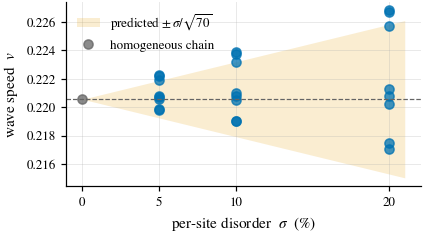


**Per-diaphragm disorder self-averages, and by roughly an order of magnitude.**

| per-site scatter $\sigma$ | spread in $v$ | mean shift in $v$ |
|:--:|:--:|:--:|
| 5% | 0.45% | +0.20% |
| 10% | 0.89% | +0.37% |
| 20% | 1.78% | +0.66% |

The spread is **linear in $\sigma$** with slope 0.089, constant to the third
decimal place across the whole range: scattering $\delta$ by $\sigma$ scatters the wave
speed by only $\approx \sigma/11$.

The comparison that matters for the reported uncertainty: at $\sigma = 10\%$, the same
tolerance used for the parametric study, per-diaphragm disorder contributes
**0.89%** against the parametric band's **9.9%** — about
11 times less. A chain whose diaphragms differ from one another
is far better behaved than a chain whose diaphragms are uniformly off-spec, so the abstract
number is rightly the parametric one.

Two caveats worth stating rather than hiding. The suppression is stronger than the front
width alone would explain: the speed is fitted over a window during which the front crosses
of order seventy sites, so it averages over those rather than over the handful the front
spans at any instant, and $1/\sqrt{70} \approx 0.12$ is the right order for the
0.089 measured. That envelope is drawn on the figure, and 17 of the 24
realisations fall inside it (71%), against the 68% a normal scatter would put inside
one standard deviation. And disorder does not merely blur the speed, it raises it
slightly — +0.37% at $\sigma = 10\%$, growing with $\sigma$ — which is small
but systematic across every seed, and not something this ensemble was designed to explain.


In [4]:
# ── Per-diaphragm disorder: does it self-average? ────────────────────────────
# Generated by scripts/disorder_sweep.py (25 runs, ~4 min on 9 workers).
# sigma is the relative site-to-site scatter in delta; sigma=0 is the exact
# homogeneous control and must reproduce the protocol-point speed.

df_dis = pd.read_csv('results/disorder.csv', comment='#')

v_hom = df_dis[df_dis.sigma == 0].v_sim.iloc[0]
rows_d = []
for s in sorted(df_dis.sigma.unique()):
    vs = df_dis[df_dis.sigma == s].v_sim.values
    rows_d.append(dict(sigma=s, n=len(vs), mean=vs.mean(),
                       spread=100*vs.std(ddof=1)/vs.mean() if len(vs) > 1 else 0.0,
                       shift=100*(vs.mean() - v_hom)/v_hom))
dis = pd.DataFrame(rows_d)
nz  = dis[dis.sigma > 0]
suppression = (nz.spread/(100*nz.sigma)).mean()      # spread as a fraction of the disorder

PARAMETRIC = 100*sigma_param/v_ens.mean()   # the measured band from the cell above

# One panel. The left-hand panel plotted three collinear points on an axis that ran
# to 10 so a parametric reference line would fit, which squashed the disorder data
# into the bottom fifth. The slope and the comparison against the parametric band
# are both single numbers, so they belong in the caption instead.
# Predicted envelope, with nothing fitted to these points. delta enters the closed
# form to the first power, so a site-to-site scatter sigma would pass into v one for
# one -- an envelope of slope 1 -- were there no averaging. The front averages over
# the ~70 sites it crosses while the speed is fitted, so what survives is
# sigma/sqrt(70). The band is +/-1 sd of that prediction.
N_AVG = 70.0
_sig  = np.linspace(0, 105*df_dis.sigma.max(), 200)
_band = _sig/100.0/np.sqrt(N_AVG)

fig, ax = plt.subplots(figsize=(width(0.62), 2.2))
ax.fill_between(_sig, v_hom*(1 - _band), v_hom*(1 + _band),
                color=C.theory, alpha=0.18, lw=0, zorder=0,
                label=r'predicted $\pm\,\sigma/\sqrt{70}$')
for s_ in sorted(df_dis.sigma.unique()):
    vs = df_dis[df_dis.sigma == s_].v_sim.values
    ax.plot(np.full(len(vs), 100*s_), vs, 'o', ms=6, alpha=0.75,
            color=C.data if s_ > 0 else C.ref,
            label='homogeneous chain' if s_ == 0 else None)
ax.axhline(v_hom, color=C.ref, lw=0.8, ls='--')
ax.set_xlabel(r'per-site disorder  $\sigma$  (%)')
ax.set_ylabel(r'wave speed  $v$')
ax.set_xticks([100*x for x in sorted(df_dis.sigma.unique())])
ax.grid(True, alpha=0.3); ax.legend(loc='upper left')
save(fig, 'disorder')
plt.show()

_nz  = df_dis[df_dis.sigma > 0]
_in  = int((( _nz.v_sim - v_hom).abs()/v_hom <= _nz.sigma/np.sqrt(N_AVG)).sum())
_pct = 100*_in/len(_nz)

_s10 = dis[np.isclose(dis.sigma, 0.10)].iloc[0]
tbl = "\n".join(f"| {100*r.sigma:.0f}% | {r.spread:.2f}% | {r.shift:+.2f}% |"
                for r in nz.itertuples())
display(Markdown(f"""
**Per-diaphragm disorder self-averages, and by roughly an order of magnitude.**

| per-site scatter $\\sigma$ | spread in $v$ | mean shift in $v$ |
|:--:|:--:|:--:|
{tbl}

The spread is **linear in $\\sigma$** with slope {suppression:.3f}, constant to the third
decimal place across the whole range: scattering $\\delta$ by $\\sigma$ scatters the wave
speed by only $\\approx \\sigma/{1/suppression:.0f}$.

The comparison that matters for the reported uncertainty: at $\\sigma = 10\\%$, the same
tolerance used for the parametric study, per-diaphragm disorder contributes
**{_s10['spread']:.2f}%** against the parametric band's **{PARAMETRIC:.1f}%** — about
{PARAMETRIC/_s10['spread']:.0f} times less. A chain whose diaphragms differ from one another
is far better behaved than a chain whose diaphragms are uniformly off-spec, so the abstract
number is rightly the parametric one.

Two caveats worth stating rather than hiding. The suppression is stronger than the front
width alone would explain: the speed is fitted over a window during which the front crosses
of order seventy sites, so it averages over those rather than over the handful the front
spans at any instant, and $1/\\sqrt{{70}} \\approx 0.12$ is the right order for the
{suppression:.3f} measured. That envelope is drawn on the figure, and {_in} of the {len(_nz)}
realisations fall inside it ({_pct:.0f}%), against the 68% a normal scatter would put inside
one standard deviation. And disorder does not merely blur the speed, it raises it
slightly — {_s10['shift']:+.2f}% at $\\sigma = 10\\%$, growing with $\\sigma$ — which is small
but systematic across every seed, and not something this ensemble was designed to explain.
"""))

### What you should see

```
| per-site scatter | spread in v | mean shift in v |
|  5%              |  0.45%      | +0.20%          |
| 10%              |  0.89%      | +0.37%          |
| 20%              |  1.78%      | +0.66%          |
```

The scatter fans out with $\sigma$ while the mean stays put. At $\sigma = 10\%$ the spread
is **0.89%**, against **9.9%** for the same tolerance applied to the whole chain at once —
eleven times smaller.

The same first-power dependence explains it. A scatter in $\delta$ passes through to $v$ one
for one, so it is neither amplified nor damped; the suppression comes entirely from the front
averaging over the ~70 sites it crosses while its speed is measured, and $1/\sqrt{70} \approx
0.12$ against the measured slope of 0.089.

**Try it yourself.** Regenerate with more realisations per $\sigma$ using
`python3 scripts/disorder_sweep.py` (25 runs, ~4 min on 9 workers). Eight realisations is
enough for the slope but thin for the scatter, and the mean shift in the third column is the
one number here with no explanation attached — it is small, systematic across every seed, and
not something this ensemble was designed to explain.

## What this delivers

**The reproducible result.**

| | |
|---|---|
| wave speed | $v = 0.2206 \pm 0.0001\ \text{(numerical)} \pm 0.0219\ \text{(parametric)}$ |
| reference value | `0.2205603205452594` |
| command | `jupyter nbconvert --to notebook --execute uq_reproducible_result.ipynb` |
| runtime | ~50 s, one core, no cluster needed |
| output | `results/protocol_point.csv` |
| ensemble | `python3 scripts/uq_sweep.py`, ~40 min on 8 cores, ships as CSVs in `results/` |

The parametric bar is more than two hundred times the numerical one. Manufacturing
precision, not the simulation, is what limits how well the speed can be known — which is the
practical conclusion of the whole exercise.

**A second test of the closed form.** Both the size of the tolerance band and the
$\delta A/\alpha$ structure behind it come out as predicted, so this section is the closed
form checked against an ensemble rather than a separate analysis bolted on at the end.

**The two uncertainties kept apart.** Tolerances that displace the whole chain (about 10%)
against per-diaphragm disorder that scrambles it internally (about 1% at the same $\sigma$).
They are easy to conflate and they answer differently.

**A note on determinism.** The protocol point is deterministic and reproduces exactly. A
regenerated *ensemble* may differ sample-for-sample across numpy major versions, since the
seeded RNG stream is not guaranteed stable, while still matching statistically. `results/`
ships the exact ensemble the reported numbers came from.